# load dataset

In [3]:
# ===============================================
# Cell 2 – Load Dataset & Basic Overview (Step 1)
# ===============================================
# On Kaggle, the dataset will be available under /kaggle/input
# Make sure you've added the dataset: 'air-india-tripadvisor-reviews'
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
CSV_PATH = '/kaggle/input/air-india-tripadvisor-reviews/air_india_reviews.csv'

df = pd.read_csv(CSV_PATH)

print('Dataset shape (rows, columns):', df.shape)
print('\nFirst 5 rows:')
print(df.head())

Dataset shape (rows, columns): (4840, 6)

First 5 rows:
              published_date  rating    type  helpful_votes  \
0  2024-03-28T17:44:04-04:00       1  review              0   
1  2024-03-28T17:24:01-04:00       1  review              0   
2  2024-03-28T16:31:49-04:00       1  review              0   
3  2024-03-27T22:43:53-04:00       3  review              0   
4  2024-03-27T08:12:41-04:00       1  review              0   

                                         title  \
0              BAD SERVICE AND BAD HOSPITALITY   
1         AI 188 and AI 187 flight nightmare !   
2  worst airline to travel dont waste ur money   
3                         Good, Can be Better!   
4                   Poor airlines and services   

                                                text  
0  From their side my baggage is broken but still...  
1  I took AI 188 noon -9th March 2024 - it was de...  
2  one of worst flight to fly with book one way l...  
3  The positive aspects on my flight were: p

In [4]:
df["rating"].value_counts()

rating
1    2049
4     922
5     739
3     615
2     515
Name: count, dtype: int64

# EDA

In [5]:
print('Column names in dataset:')
print(df.columns.tolist())

print('\nData types and non-null counts:')
print(df.info())

print('\nBasic statistical summary (numeric columns):')
print(df.describe())

Column names in dataset:
['published_date', 'rating', 'type', 'helpful_votes', 'title', 'text']

Data types and non-null counts:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4840 entries, 0 to 4839
Data columns (total 6 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   published_date  4840 non-null   object
 1   rating          4840 non-null   int64 
 2   type            4840 non-null   object
 3   helpful_votes   4840 non-null   int64 
 4   title           4840 non-null   object
 5   text            4840 non-null   object
dtypes: int64(2), object(4)
memory usage: 227.0+ KB
None

Basic statistical summary (numeric columns):
            rating  helpful_votes
count  4840.000000    4840.000000
mean      2.542769       0.651033
std       1.546760       2.588288
min       1.000000       0.000000
25%       1.000000       0.000000
50%       2.000000       0.000000
75%       4.000000       1.000000
max       5.000000     130.000000


In [6]:
print('Missing values per column:')
print(df.isna().sum().sort_values(ascending=False))

num_duplicates = df.duplicated().sum()
print('\nNumber of duplicate rows:', num_duplicates)

Missing values per column:
published_date    0
rating            0
type              0
helpful_votes     0
title             0
text              0
dtype: int64

Number of duplicate rows: 0


In [7]:
df=df[["text","rating"]]

In [8]:
df

,text,rating
0,From their side my baggage is broken but still...,1
1,I took AI 188 noon -9th March 2024 - it was de...,1
2,one of worst flight to fly with book one way l...,1
3,The positive aspects on my flight were: punctu...,3
4,"Extremally poor services in flight, aircraft i...",1
...,...,...
4835,One of the better options to fly in Economy cl...,4
4836,AI operates dreamliner aircraft on Delhi to Du...,5
4837,I travelled recently with Air India and it was...,1
4838,"The destination was so close, therefore Flight...",4


In [9]:
df.sample(30).to_csv("sample.csv")

In [10]:
df["rating"]=df["rating"]-1

###  pre processing 

In [11]:
import re
import string
import nltk
from nltk.corpus import stopwords

# Download stopwords (only first time)
nltk.download('stopwords')
stop_words = set(stopwords.words("english"))

def clean_text(text):
    # 1. Convert to lowercase
    text = text.lower()
    
    # 2. Remove URLs
    text = re.sub(r'http\S+|www\S+|https\S+', '', text, flags=re.MULTILINE)
    
    # 3. Remove HTML tags
    text = re.sub(r'<.*?>', '', text)
    
    # 4. Remove punctuation
    text = text.translate(str.maketrans('', '', string.punctuation))
    
    # 5. Remove special characters & numbers
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    
    # 6. Remove extra spaces
    text = re.sub(r'\s+', ' ', text).strip()
    


    
    return text


[nltk_data] Downloading package stopwords to /usr/share/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


In [12]:
df['clean_text'] = df['text'].astype(str).apply(clean_text)


In [13]:
df

,text,rating,clean_text
0,From their side my baggage is broken but still...,0,from their side my baggage is broken but still...
1,I took AI 188 noon -9th March 2024 - it was de...,0,i took ai noon th march it was delayed left pm...
2,one of worst flight to fly with book one way l...,0,one of worst flight to fly with book one way l...
3,The positive aspects on my flight were: punctu...,2,the positive aspects on my flight were punctua...
4,"Extremally poor services in flight, aircraft i...",0,extremally poor services in flight aircraft is...
...,...,...,...
4835,One of the better options to fly in Economy cl...,3,one of the better options to fly in economy cl...
4836,AI operates dreamliner aircraft on Delhi to Du...,4,ai operates dreamliner aircraft on delhi to du...
4837,I travelled recently with Air India and it was...,0,i travelled recently with air india and it was...
4838,"The destination was so close, therefore Flight...",3,the destination was so close therefore flight ...


In [14]:
import torch
from transformers import BertTokenizer, BertForSequenceClassification

2026-01-12 08:32:12.386725: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1768206732.588293      47 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1768206732.642924      47 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

In [15]:
from transformers import BertTokenizer

tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')

print("Tokenizer loaded successfully!")


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

Tokenizer loaded successfully!


In [16]:
from sklearn.model_selection import train_test_split

# Stratified split based on 'rating'
train_df, test_df = train_test_split(
    df,
    test_size=0.2,          # 20% test data
    stratify=df['rating'],  # important!
    random_state=42
)

print("Train size:", len(train_df))
print("Test size:", len(test_df))

# Check rating distribution
print("\nTrain rating distribution:")
print(train_df['rating'].value_counts())

print("\nTest rating distribution:")
print(test_df['rating'].value_counts())


Train size: 3872
Test size: 968

Train rating distribution:
rating
0    1639
3     738
4     591
2     492
1     412
Name: count, dtype: int64

Test rating distribution:
rating
0    410
3    184
4    148
2    123
1    103
Name: count, dtype: int64


In [17]:
from datasets import Dataset, DatasetDict

# Convert pandas DataFrames → HF Datasets
train_dataset = Dataset.from_pandas(train_df)
test_dataset = Dataset.from_pandas(test_df)

In [18]:
def tokenize_function(batch):
    return tokenizer(
        batch["clean_text"],
        padding="max_length",
        truncation=True,
        max_length=384 
    )


In [19]:
train_tokenized = train_dataset.map(tokenize_function, batched=True)
test_tokenized = test_dataset.map(tokenize_function, batched=True)


Map:   0%|          | 0/3872 [00:00<?, ? examples/s]

Map:   0%|          | 0/968 [00:00<?, ? examples/s]

In [20]:
train_tokenized = train_tokenized.rename_column("rating", "labels")
test_tokenized = test_tokenized.rename_column("rating", "labels")

In [21]:
train_tokenized.set_format(type="torch")
test_tokenized.set_format(type="torch") 

In [22]:
from transformers import BertForSequenceClassification

model = BertForSequenceClassification.from_pretrained(
    'bert-base-uncased',
    num_labels=5  # number of rating classes
)


model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [23]:
from transformers import TrainingArguments

training_args = TrainingArguments(
    output_dir="./bert_rating_model",
    num_train_epochs=3,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    learning_rate=2e-5,
    weight_decay=0.01,
    
    # --- CHANGED SETTINGS ---
    eval_strategy="steps",   
    eval_steps=100,           # Changed from 500 to 100 (checks accuracy every 100 steps)
    save_steps=100,           # Changed from 500 to 100 (saves model every 100 steps)
    logging_steps=50,         # Log loss more frequently
    # ------------------------
    
    save_total_limit=2,
    load_best_model_at_end=True,
    metric_for_best_model="accuracy",
    logging_dir="./logs",
    report_to="none"
)

In [24]:
!pip install evaluate

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 2.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 47.7/47.7 MB 41.7 MB/s eta 0:00:00:00:0100:01
  Attempting uninstall: pyarrow
    Found existing installation: pyarrow 19.0.1
    Uninstalling pyarrow-19.0.1:
      Successfully uninstalled pyarrow-19.0.1
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
bigframes 2.12.0 requires google-cloud-bigquery-storage<3.0.0,>=2.30.0, which is not installed.
pylibcudf-cu12 25.2.2 requires pyarrow<20.0.0a0,>=14.0.0; platform_machine == "x86_64", but you have pyarrow 22.0.0 which is incompatible.
cudf-cu12 25.2.2 requires pyarrow<20.0.0a0,>=14.0.0; platform_machine == "x86_64", but you have pyarrow 22.0.0 which is incompatible.
bigframes 2.12.0 requires rich<14,>=12.4.4, but you have rich 14.2.0 which is incompatible.
cudf-polars-cu12 25.6.0 requires pyli

In [25]:
import evaluate
import numpy as np

# Load evaluation metrics
accuracy_metric = evaluate.load("accuracy")
precision_metric = evaluate.load("precision")
recall_metric = evaluate.load("recall")
f1_metric = evaluate.load("f1")

# Define a compute_metrics function for Trainer
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=-1)
    
    acc = accuracy_metric.compute(predictions=predictions, references=labels)["accuracy"]
    precision = precision_metric.compute(predictions=predictions, references=labels, average="weighted")["precision"]
    recall = recall_metric.compute(predictions=predictions, references=labels, average="weighted")["recall"]
    f1 = f1_metric.compute(predictions=predictions, references=labels, average="weighted")["f1"]
    
    return {
        "accuracy": acc,
        "precision": precision,
        "recall": recall,
        "f1": f1
    }


In [26]:
from transformers import Trainer

trainer = Trainer(
    model=model,                         # your BertForSequenceClassification model
    args=training_args,                   # the TrainingArguments you defined
    train_dataset=train_tokenized,        # tokenized training dataset
    eval_dataset=test_tokenized,          # tokenized evaluation/test dataset
    compute_metrics=compute_metrics       # the metrics function you defined
)


In [27]:
trainer.train()


Step,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1
100,0.930700,0.940782,0.635331,0.546201,0.635331,0.559931
200,0.893200,0.856066,0.627066,0.639172,0.627066,0.608946
300,0.720100,0.800506,0.646694,0.626122,0.646694,0.634001
400,0.667200,0.809835,0.664256,0.641000,0.664256,0.643238
500,0.632900,0.807597,0.650826,0.650053,0.650826,0.647432
600,0.526900,0.836821,0.649793,0.645449,0.649793,0.644273
700,0.533900,0.836919,0.651860,0.646456,0.651860,0.647250


/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


TrainOutput(global_step=726, training_loss=0.7374827776401824, metrics={'train_runtime': 609.3976, 'train_samples_per_second': 19.061, 'train_steps_per_second': 1.191, 'total_flos': 2292285257146368.0, 'train_loss': 0.7374827776401824, 'epoch': 3.0})

In [28]:
trainer.evaluate()

{'eval_loss': 0.8098347783088684,
 'eval_accuracy': 0.6642561983471075,
 'eval_precision': 0.6410000658723065,
 'eval_recall': 0.6642561983471075,
 'eval_f1': 0.6432382586563806,
 'eval_runtime': 11.2607,
 'eval_samples_per_second': 85.963,
 'eval_steps_per_second': 5.417,
 'epoch': 3.0}

In [29]:
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np

# Get predictions from the trainer
predictions_output = trainer.predict(test_tokenized)
logits = predictions_output.predictions
labels = predictions_output.label_ids

# Convert logits → predicted class
preds = np.argmax(logits, axis=-1)

# Print classification report
report = classification_report(labels, preds, target_names=[f"Rating_{i}" for i in range(5)])
print("Classification Report:\n", report)

# Optional: Confusion matrix
cm = confusion_matrix(labels, preds)
print("Confusion Matrix:\n", cm)


Classification Report:
               precision    recall  f1-score   support

    Rating_0       0.80      0.92      0.86       410
    Rating_1       0.39      0.21      0.27       103
    Rating_2       0.41      0.37      0.39       123
    Rating_3       0.62      0.44      0.51       184
    Rating_4       0.59      0.78      0.67       148

    accuracy                           0.66       968
   macro avg       0.56      0.55      0.54       968
weighted avg       0.64      0.66      0.64       968

Confusion Matrix:
 [[378  16  15   0   1]
 [ 60  22  17   2   2]
 [ 29  17  46  21  10]
 [  2   2  31  81  68]
 [  1   0   4  27 116]]


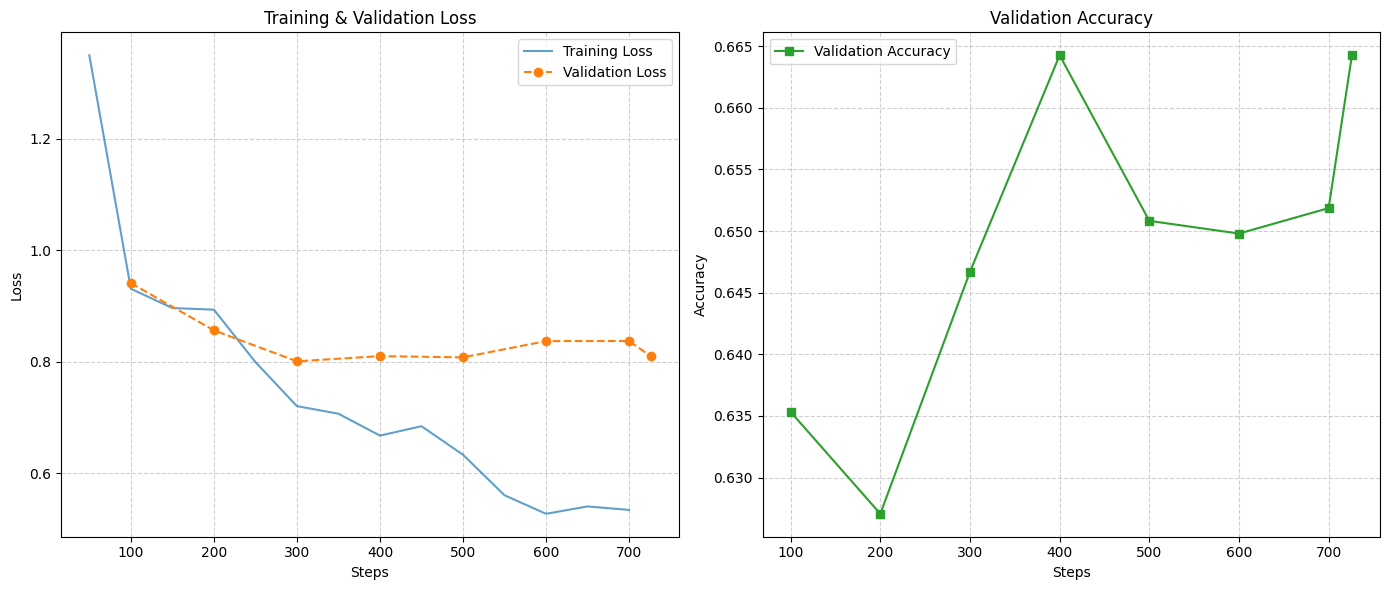

In [30]:
import matplotlib.pyplot as plt

# 1. Extract logs from the trainer
history = trainer.state.log_history

# 2. Initialize lists to store metrics
train_loss = []
train_steps = []
eval_loss = []
eval_acc = []
eval_steps = []

# 3. Parse the history
for entry in history:
    # Training logs usually contain 'loss' and 'step'
    if 'loss' in entry and 'step' in entry:
        train_loss.append(entry['loss'])
        train_steps.append(entry['step'])
    
    # Evaluation logs contain 'eval_loss', 'eval_accuracy', etc.
    if 'eval_loss' in entry:
        eval_loss.append(entry['eval_loss'])
        eval_acc.append(entry['eval_accuracy'])
        eval_steps.append(entry['step'])

# 4. Plotting
plt.figure(figsize=(14, 6))

# --- Plot 1: Training vs Validation Loss ---
plt.subplot(1, 2, 1)
plt.plot(train_steps, train_loss, label='Training Loss', color='#1f77b4', alpha=0.7)
plt.plot(eval_steps, eval_loss, label='Validation Loss', color='#ff7f0e', marker='o', linestyle='--')
plt.title('Training & Validation Loss')
plt.xlabel('Steps')
plt.ylabel('Loss')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)

# --- Plot 2: Validation Accuracy ---
plt.subplot(1, 2, 2)
plt.plot(eval_steps, eval_acc, label='Validation Accuracy', color='#2ca02c', marker='s')
plt.title('Validation Accuracy')
plt.xlabel('Steps')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

In [31]:
import torch

def predict_rating(text, model, tokenizer, return_original_rating=True, max_length=384):
    """
    Predict the rating of a single text using a trained BERT model.
    
    Parameters:
    - text (str): The text to predict.
    - model: Trained BertForSequenceClassification model.
    - tokenizer: Corresponding BERT tokenizer.
    - return_original_rating (bool): If True, returns 1-5; else 0-4.
    - max_length (int): Max token length for BERT input.
    
    Returns:
    - int: Predicted rating.
    """
    
    device = "cuda" if torch.cuda.is_available() else "cpu"
    model.to(device)
    
    # Tokenize
    inputs = tokenizer(
        text,
        padding="max_length",
        truncation=True,
        max_length=max_length,
        return_tensors="pt"
    )
    
    inputs = {k: v.to(device) for k, v in inputs.items()}
    
    # Get prediction
    with torch.no_grad():
        outputs = model(**inputs)
        logits = outputs.logits
        prediction = torch.argmax(logits, dim=-1).item()
    
    if return_original_rating:
        prediction += 1  # convert 0-4 → 1-5
    
    return prediction


In [32]:
text = "The flight experience was excellent and the staff were very helpful."
predicted_rating = predict_rating(text, model, tokenizer)
print("Predicted Rating:", predicted_rating)


Predicted Rating: 5


In [33]:
text = "The flight experience was bad and the staff were very rude."
predicted_rating = predict_rating(text, model, tokenizer)
print("Predicted Rating:", predicted_rating)


Predicted Rating: 1


Gradio

In [34]:
# Install gradio if not already installed (uncomment if needed)
# !pip install gradio

import gradio as gr
import torch

# 1. Define the prediction wrapper function
def app_predict(review_text):
    # Ensure model is in eval mode
    model.eval()
    
    # Use your existing prediction logic
    rating = predict_rating(review_text, model, tokenizer)
    
    # Add emojis and text for the app display
    if rating >= 4:
        sentiment = "Positive 😊"
        color = "green"
    elif rating == 3:
        sentiment = "Neutral 😐"
        color = "orange"
    else:
        sentiment = "Negative 😠"
        color = "red"
        
    stars = "⭐" * rating
    return f"{stars}\n({sentiment})"

# 2. Define Custom CSS to look like a Phone
mobile_css = """
#app-container {
    max-width: 380px;       /* Width of a standard mobile phone */
    margin: 0 auto;         /* Center the phone on the page */
    border: 10px solid #222;/* Phone bezel/border */
    border-radius: 25px;    /* Rounded corners */
    padding: 20px;
    background-color: white;
    box-shadow: 0 10px 25px rgba(0,0,0,0.3);
}
#submit-btn {
    background-color: #E60000 !important; /* Air India Red */
    color: white !important;
}
"""

# 3. Build the Interface
with gr.Blocks(css=mobile_css) as demo:
    with gr.Column(elem_id="app-container"):
        gr.Markdown("### ⭐ Review2Stars")
        
        # Input area
        inp = gr.Textbox(
            placeholder="Type your flight experience...",
            label="Write Review",
            lines=4
        )
        
        # Button
        btn = gr.Button("Analyze Rating", elem_id="submit-btn")
        
        # Output area
        out = gr.Textbox(label="Predicted Rating")
        
        # Examples inside the phone screen
        gr.Examples(
            examples=[
                ["The staff was very polite and the food was delicious."],
                ["My luggage was broken and the flight was delayed by 3 hours."],
                ["It was an okay flight, legroom was a bit tight but acceptable."]
            ],
            inputs=inp,
            label="Tap an example:"
        )
        
        # Connect the button to the function
        btn.click(fn=app_predict, inputs=inp, outputs=out)

# 4. Launch
demo.launch()

* Running on local URL:  http://127.0.0.1:7860
It looks like you are running Gradio on a hosted Jupyter notebook, which requires `share=True`. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

* Running on public URL: https://97c526ef10a1b7983f.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
